# Step 8 — Validate the findings

This notebook checks whether the three Step 7 findings remain stable when
the data is split, the assumptions are changed, and uncertainty is
reported.

The validation stays simple:

1. **Health risk:** compare a development sample with a holdout sample,
   add a confidence interval, and change the risk thresholds.
2. **Failure archetypes:** check whether the main pattern repeats in a
   holdout sample and whether sector findings remain stable.
3. **Funding outcomes:** use a stratified holdout test, address outcome
   imbalance, report predictive metrics, and test different cohort sizes.

## Important validation limit

The available data does not support the same validation for all three
questions.

- The startup-metrics data is synthetic and its health label is created
  from runway and LTV/CAC rules. It has no later failure or survival
  outcome. We can test **consistency and sensitivity**, not real-world
  prediction.
- The failure data contains failed startups only. It can show which
  factors co-occur among failures, but it cannot estimate the probability
  that an active startup will fail.
- The Crunchbase data has an observed status label, so a holdout test is
  possible. The result is still an **association**, not a causal effect of
  funding.

In [1]:
# Import only the libraries needed for validation.
from pathlib import Path
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

RANDOM_SEED = 42
N_BOOTSTRAP = 2000

# Find the project whether the notebook runs from the project root,
# the notebooks folder, or the current demonstration workspace.
BASE_DIR = Path.cwd()
if not (BASE_DIR / "data" / "processed").exists():
    if (BASE_DIR.parent / "data" / "processed").exists():
        BASE_DIR = BASE_DIR.parent
    elif (BASE_DIR / "step4_test_project" / "data" / "processed").exists():
        BASE_DIR = BASE_DIR / "step4_test_project"

PROCESSED_DIR = BASE_DIR / "data" / "processed"
FIGURE_DIR = BASE_DIR / "outputs" / "figures"
TABLE_DIR = BASE_DIR / "outputs" / "tables"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")


def save_figure(file_name):
    # Save the chart and also show it in the notebook.
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / file_name, dpi=150, bbox_inches="tight")
    plt.show()


def bootstrap_mean_ci(values, seed=RANDOM_SEED):
    # Return a simple 95% bootstrap interval for a mean or proportion.
    values = np.asarray(values, dtype=float)
    rng = np.random.default_rng(seed)
    estimates = []

    for _ in range(N_BOOTSTRAP):
        sample = rng.choice(values, size=len(values), replace=True)
        estimates.append(sample.mean())

    return np.percentile(estimates, [2.5, 97.5])


def bootstrap_difference_ci(high_values, low_values, seed=RANDOM_SEED):
    # Return a 95% interval for the difference between two proportions.
    high_values = np.asarray(high_values, dtype=float)
    low_values = np.asarray(low_values, dtype=float)
    rng = np.random.default_rng(seed)
    estimates = []

    for _ in range(N_BOOTSTRAP):
        high_sample = rng.choice(
            high_values, size=len(high_values), replace=True
        )
        low_sample = rng.choice(
            low_values, size=len(low_values), replace=True
        )
        estimates.append(high_sample.mean() - low_sample.mean())

    return np.percentile(estimates, [2.5, 97.5])

## Load the Step 5 feature tables

In [2]:
failure_file = PROCESSED_DIR / "failure_feature_table.csv"
crunchbase_file = PROCESSED_DIR / "crunchbase_feature_table.csv"
metrics_file = PROCESSED_DIR / "startup_metrics_feature_table.csv"

required_files = [failure_file, crunchbase_file, metrics_file]
missing_files = [str(file) for file in required_files if not file.exists()]

if missing_files:
    raise FileNotFoundError(
        f"Missing Step 5 files: {missing_files}. Run Step 5 first."
    )

failure = pd.read_csv(failure_file, low_memory=False)
crunchbase = pd.read_csv(crunchbase_file, low_memory=False)
startup_metrics = pd.read_csv(metrics_file)

print(f"Failure records:        {len(failure):,}")
print(f"Crunchbase companies:   {len(crunchbase):,}")
print(f"Synthetic metric rows:  {len(startup_metrics):,}")

Failure records:        409
Crunchbase companies:   66,368
Synthetic metric rows:  200


**Note.** The three tables remain separate. Validation does not assume
that records across the datasets refer to the same companies.

# 1. Validate the health-risk finding

Step 7 found that runway was the most common immediate risk signal. We
first check whether the High Risk share is similar in a 70% development
sample and a 30% holdout sample. The split is stratified by startup stage
so both samples contain a similar stage mix.

In [3]:
health = startup_metrics[startup_metrics["analysis_eligible"]].copy()

# Recreate the transparent Step 7 High Risk rule.
health["high_risk_check"] = (
    (health["runway_months"] < 6)
    | (health["ltv_cac_ratio"] <= 2)
)

health_development, health_holdout = train_test_split(
    health,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=health["stage"],
)

health_split_summary = pd.DataFrame([
    {
        "Sample": "Development (70%)",
        "Startups": len(health_development),
        "High Risk share (%)":
            100 * health_development["high_risk_check"].mean(),
    },
    {
        "Sample": "Holdout (30%)",
        "Startups": len(health_holdout),
        "High Risk share (%)":
            100 * health_holdout["high_risk_check"].mean(),
    },
    {
        "Sample": "Full sample",
        "Startups": len(health),
        "High Risk share (%)":
            100 * health["high_risk_check"].mean(),
    },
])
health_split_summary["High Risk share (%)"] = health_split_summary[
    "High Risk share (%)"
].round(1)

health_ci = 100 * bootstrap_mean_ci(health["high_risk_check"])

health_split_summary.to_csv(
    TABLE_DIR / "step8_health_holdout_summary.csv", index=False
)

print(health_split_summary.to_string(index=False))
print()
print(
    "Full-sample High Risk share: "
    f"{100 * health['high_risk_check'].mean():.1f}% "
    f"(95% bootstrap interval: {health_ci[0]:.1f}% to "
    f"{health_ci[1]:.1f}%)"
)

           Sample  Startups  High Risk share (%)
Development (70%)       140                 62.9
    Holdout (30%)        60                 66.7
      Full sample       200                 64.0

Full-sample High Risk share: 64.0% (95% bootstrap interval: 57.5% to 70.5%)


**Result note.** The High Risk share is 62.9% in the development sample
and 66.7% in the holdout sample. The full-sample estimate is 64.0%, with
a 95% bootstrap interval of about 57.5% to 70.5%. The split therefore
reproduces the same broad result. This is a stability check only because
the health label has no independent later outcome.

## Health-rule robustness

The next check changes both thresholds. A robust conclusion should not
disappear after a small reasonable change, but the exact percentage is
expected to move.

LTV/CAC cutoff           1.5   2.0   2.5
Runway cutoff (months)                  
3                       35.0  46.0  53.0
6                       55.5  64.0  68.5
9                       76.5  82.5  85.0


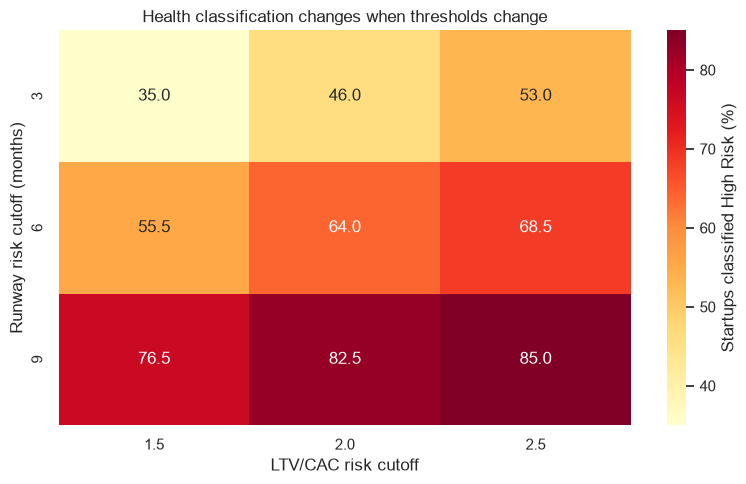

In [4]:
runway_cutoffs = [3, 6, 9]
ltv_cac_cutoffs = [1.5, 2.0, 2.5]
sensitivity_rows = []

for runway_cutoff in runway_cutoffs:
    for ltv_cac_cutoff in ltv_cac_cutoffs:
        high_risk_share = 100 * (
            (health["runway_months"] < runway_cutoff)
            | (health["ltv_cac_ratio"] <= ltv_cac_cutoff)
        ).mean()

        sensitivity_rows.append({
            "Runway cutoff (months)": runway_cutoff,
            "LTV/CAC cutoff": ltv_cac_cutoff,
            "High Risk share (%)": round(high_risk_share, 1),
        })

health_sensitivity = pd.DataFrame(sensitivity_rows)
health_sensitivity.to_csv(
    TABLE_DIR / "step8_health_threshold_sensitivity.csv", index=False
)

sensitivity_matrix = health_sensitivity.pivot(
    index="Runway cutoff (months)",
    columns="LTV/CAC cutoff",
    values="High Risk share (%)",
)

print(sensitivity_matrix.to_string())

plt.figure(figsize=(8, 5))
sns.heatmap(
    sensitivity_matrix,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    cbar_kws={"label": "Startups classified High Risk (%)"},
)
plt.title("Health classification changes when thresholds change")
plt.xlabel("LTV/CAC risk cutoff")
plt.ylabel("Runway risk cutoff (months)")
save_figure("step8_01_health_sensitivity.png")

**Result note.** The High Risk share ranges from 35.0% under the strictest
thresholds to 85.0% under the broadest thresholds. Runway remains an
important signal, but the exact risk rate is highly dependent on the
chosen business rules. The thresholds should therefore be treated as
adjustable screening assumptions, not universal facts.

# 2. Validate the failure-archetype finding

The failure table is divided into a 70% development sample and a 30%
holdout sample, stratified by sector. We test whether the dominant
Large-incumbent plus Competition pair appears at a similar rate in both
samples.

In [5]:
failure_development, failure_holdout = train_test_split(
    failure,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=failure["Sector"],
)


def competitive_pair_share(data):
    pair = data["Giants"].eq(1) & data["Competition"].eq(1)
    return 100 * pair.mean()


full_pair = failure["Giants"].eq(1) & failure["Competition"].eq(1)
failure_pair_ci = 100 * bootstrap_mean_ci(full_pair)

failure_pair_summary = pd.DataFrame([
    {
        "Sample": "Development (70%)",
        "Records": len(failure_development),
        "Large-incumbent plus Competition share (%)":
            competitive_pair_share(failure_development),
    },
    {
        "Sample": "Holdout (30%)",
        "Records": len(failure_holdout),
        "Large-incumbent plus Competition share (%)":
            competitive_pair_share(failure_holdout),
    },
    {
        "Sample": "Full sample",
        "Records": len(failure),
        "Large-incumbent plus Competition share (%)":
            competitive_pair_share(failure),
    },
])
failure_pair_summary[
    "Large-incumbent plus Competition share (%)"
] = failure_pair_summary[
    "Large-incumbent plus Competition share (%)"
].round(1)

# Compare the five most frequent exact combinations in both samples.
development_top_five = list(
    failure_development["risk_combination"].value_counts().head(5).index
)
holdout_top_five = list(
    failure_holdout["risk_combination"].value_counts().head(5).index
)
top_five_overlap = len(
    set(development_top_five).intersection(holdout_top_five)
)

exact_combination_comparison = pd.DataFrame({
    "Rank": range(1, 6),
    "Development top combination": development_top_five,
    "Holdout top combination": holdout_top_five,
})

failure_pair_summary.to_csv(
    TABLE_DIR / "step8_failure_pair_holdout.csv", index=False
)
exact_combination_comparison.to_csv(
    TABLE_DIR / "step8_failure_combination_holdout.csv", index=False
)

print(failure_pair_summary.to_string(index=False))
print()
print(
    "Full-sample pair share 95% bootstrap interval: "
    f"{failure_pair_ci[0]:.1f}% to {failure_pair_ci[1]:.1f}%"
)
print(f"Top-five exact-combination overlap: {top_five_overlap} of 5")
print()
print(exact_combination_comparison.to_string(index=False))

           Sample  Records  Large-incumbent plus Competition share (%)
Development (70%)      286                                        57.7
    Holdout (30%)      123                                        59.3
      Full sample      409                                        58.2

Full-sample pair share 95% bootstrap interval: 53.5% to 62.8%
Top-five exact-combination overlap: 2 of 5

 Rank                           Development top combination                       Holdout top combination
    1                                  Giants + Competition Giants + Competition + Acquisition Stagnation
    2         Giants + Competition + Acquisition Stagnation                          Giants + Competition
    3                Giants + Competition + Execution Flaws           Giants + Competition + Trend Shifts
    4                      Giants + No Budget + Competition        Giants + Competition + Poor Market Fit
    5 Giants + Competition + Poor Market Fit + Niche Limits               Giant

**Result note.** The dominant pair appears in 57.7% of development
records and 59.3% of holdout records. The full-sample 95% interval is
approximately 53.5% to 62.8%. This supports the stability of the broad
competitive-pressure pattern. Only three of the five leading exact
combinations overlap, showing that detailed combinations are less stable.

## Sector-level robustness

                         Sector Development top factor  Development top factor share (%)     Holdout top factor  Holdout top factor share (%)  Same top factor
Accommodation and Food Services High Operational Costs                              50.0 High Operational Costs                          62.5             True
          Finance and Insurance        Poor Market Fit                              30.3 Acquisition Stagnation                          35.7            False
                    Health Care        Poor Market Fit                              50.0        Poor Market Fit                          38.9             True
                    Information Acquisition Stagnation                              32.1 Acquisition Stagnation                          40.4             True
                  Manufacturing              No Budget                              57.1              No Budget                          44.4             True
                   Retail Trade           Nich

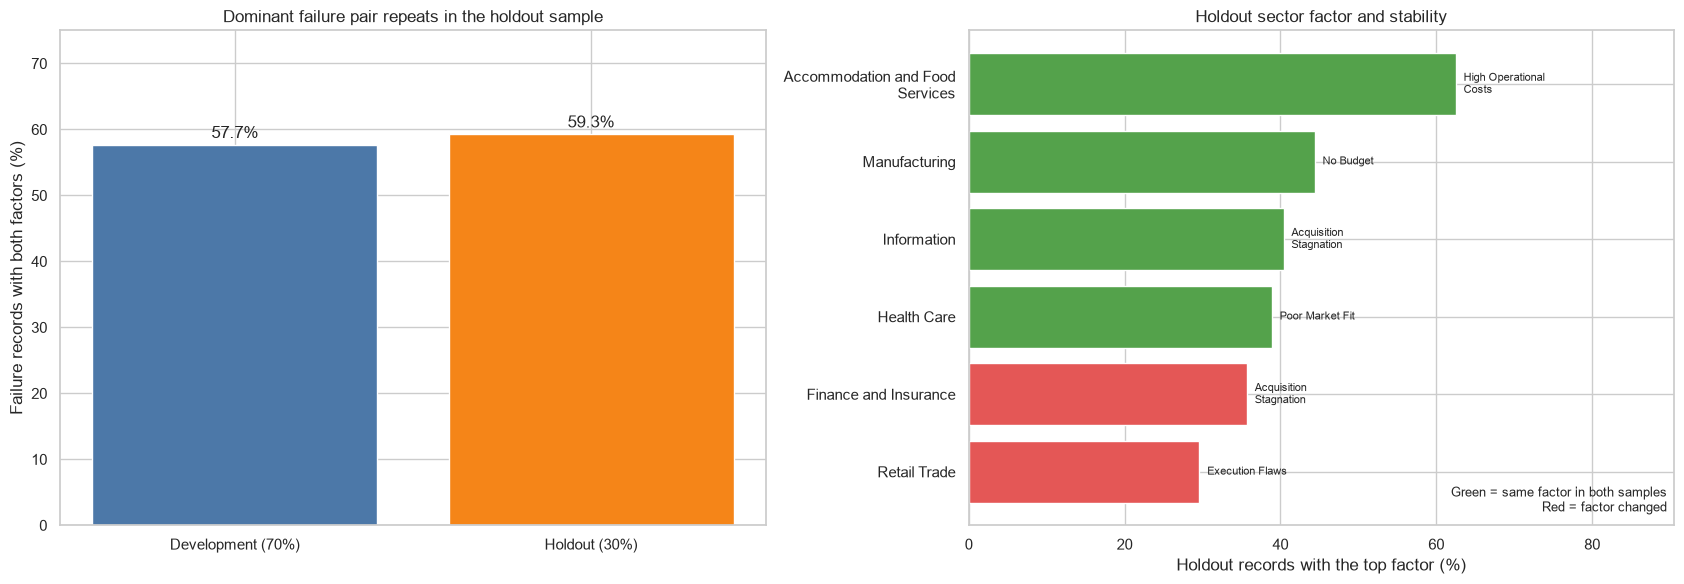

In [6]:
secondary_flags = [
    "No Budget",
    "Poor Market Fit",
    "Acquisition Stagnation",
    "Platform Dependency",
    "High Operational Costs",
    "Monetization Failure",
    "Niche Limits",
    "Execution Flaws",
    "Trend Shifts",
    "Toxicity/Trust Issues",
    "Regulatory Pressure",
    "Overhype",
]


def top_secondary_factor_by_sector(data, sample_name):
    # Calculate each factor's prevalence inside each sector.
    rates = data.groupby("Sector")[secondary_flags].mean() * 100

    result = pd.DataFrame({
        "Sector": rates.index,
        f"{sample_name} top factor": rates.idxmax(axis=1),
        f"{sample_name} top factor share (%)": rates.max(axis=1),
    }).reset_index(drop=True)

    return result


development_sector = top_secondary_factor_by_sector(
    failure_development, "Development"
)
holdout_sector = top_secondary_factor_by_sector(
    failure_holdout, "Holdout"
)

sector_stability = development_sector.merge(holdout_sector, on="Sector")
sector_stability["Same top factor"] = (
    sector_stability["Development top factor"]
    == sector_stability["Holdout top factor"]
)
sector_stability["Development top factor share (%)"] = sector_stability[
    "Development top factor share (%)"
].round(1)
sector_stability["Holdout top factor share (%)"] = sector_stability[
    "Holdout top factor share (%)"
].round(1)

stable_sector_count = int(sector_stability["Same top factor"].sum())
sector_count = len(sector_stability)

sector_stability.to_csv(
    TABLE_DIR / "step8_failure_sector_stability.csv", index=False
)

print(sector_stability.to_string(index=False))
print()
print(
    f"Matching sector-level top factors: "
    f"{stable_sector_count} of {sector_count} sectors"
)

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

pair_plot = failure_pair_summary.iloc[:2]
axes[0].bar(
    pair_plot["Sample"],
    pair_plot["Large-incumbent plus Competition share (%)"],
    color=["#4C78A8", "#F58518"],
)
axes[0].set_title("Dominant failure pair repeats in the holdout sample")
axes[0].set_ylabel("Failure records with both factors (%)")
axes[0].set_xlabel("")
axes[0].set_ylim(0, 75)
for position, value in enumerate(
    pair_plot["Large-incumbent plus Competition share (%)"]
):
    axes[0].text(position, value + 1, f"{value:.1f}%", ha="center")

sector_plot = sector_stability.sort_values(
    "Holdout top factor share (%)"
).copy()
sector_plot["Sector label"] = sector_plot["Sector"].map(
    lambda value: textwrap.fill(value, width=24)
)
colors = sector_plot["Same top factor"].map(
    {True: "#54A24B", False: "#E45756"}
)
axes[1].barh(
    sector_plot["Sector label"],
    sector_plot["Holdout top factor share (%)"],
    color=colors,
)
axes[1].set_title("Holdout sector factor and stability")
axes[1].set_xlabel("Holdout records with the top factor (%)")
axes[1].set_ylabel("")

for position, (_, row) in enumerate(sector_plot.iterrows()):
    factor_label = textwrap.fill(row["Holdout top factor"], width=20)
    axes[1].text(
        row["Holdout top factor share (%)"] + 1,
        position,
        factor_label,
        va="center",
        fontsize=8,
    )

axes[1].set_xlim(
    0,
    max(sector_plot["Holdout top factor share (%)"]) + 28,
)
axes[1].text(
    0.99,
    0.02,
    "Green = same factor in both samples\nRed = factor changed",
    transform=axes[1].transAxes,
    ha="right",
    va="bottom",
    fontsize=9,
)

save_figure("step8_02_failure_holdout.png")

**Result note.** Four of six sectors retain the same leading secondary
factor. Finance and Insurance and Retail Trade change their leading
factor in the holdout sample. The broad competitive pattern is stable,
but sector-specific recommendations should be presented with uncertainty,
especially where sector samples are small.

# 3. Validate the funding-outcome benchmark

This is the only analysis with an observed outcome suitable for a
predictive holdout test.

- **Target:** acquired or IPO versus other observed statuses.
- **Predictor:** funding percentile inside the comparable peer cohort.
- **Split:** 80% development and 20% holdout, stratified by outcome.
- **Class imbalance:** the model uses balanced class weights. Evaluation
  uses balanced accuracy, ROC-AUC, precision, recall, and F1 rather than
  ordinary accuracy alone.

In [7]:
funding_base = crunchbase[
    crunchbase["funding_total_usd"].notna()
    & crunchbase["primary_category"].ne("Unknown")
    & crunchbase["country_code"].ne("UNKNOWN")
    & crunchbase["founded_cohort"].ne("Unknown")
].copy()

funding_base["observed_exit"] = funding_base["status"].isin(
    ["acquired", "ipo"]
)

# Use the same Step 7 minimum: 30 records and 5 observed exits.
cohort_eligibility = (
    funding_base.groupby("peer_cohort")
    .agg(
        funding_records=("name", "size"),
        observed_exit_records=("observed_exit", "sum"),
    )
)
eligible_cohorts = cohort_eligibility[
    (cohort_eligibility["funding_records"] >= 30)
    & (cohort_eligibility["observed_exit_records"] >= 5)
].index

funding = funding_base[
    funding_base["peer_cohort"].isin(eligible_cohorts)
].copy()

# Rank funding inside each comparable cohort.
funding["funding_percentile"] = (
    funding.groupby("peer_cohort")["funding_total_usd"]
    .rank(pct=True, method="average")
)

quartile_order = [
    "Bottom quarter",
    "Lower-middle quarter",
    "Upper-middle quarter",
    "Top quarter",
]
funding["funding_quartile"] = pd.cut(
    funding["funding_percentile"],
    bins=[0, 0.25, 0.50, 0.75, 1],
    labels=quartile_order,
    include_lowest=True,
)

funding_development, funding_holdout = train_test_split(
    funding,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=funding["observed_exit"],
)

class_balance = pd.DataFrame([
    {
        "Outcome": "Observed exit",
        "Companies": int(funding["observed_exit"].sum()),
        "Share (%)": 100 * funding["observed_exit"].mean(),
    },
    {
        "Outcome": "No observed exit",
        "Companies": int((~funding["observed_exit"]).sum()),
        "Share (%)": 100 * (~funding["observed_exit"]).mean(),
    },
])
class_balance["Share (%)"] = class_balance["Share (%)"].round(1)

print(f"Eligible peer cohorts: {len(eligible_cohorts):,}")
print(f"Companies in benchmark: {len(funding):,}")
print()
print("Outcome class balance:")
print(class_balance.to_string(index=False))

Eligible peer cohorts: 97
Companies in benchmark: 15,878

Outcome class balance:
         Outcome  Companies  Share (%)
   Observed exit       2808       17.7
No observed exit      13070       82.3


**Class-imbalance note.** Only 17.7% of companies have an observed exit.
A model that predicts the majority class for everyone could appear
accurate while missing every exit. Balanced class weights and
class-sensitive metrics reduce this problem, although they do not create
missing information.

In [8]:
# Fit a simple, interpretable logistic model.
funding_model = LogisticRegression(
    class_weight="balanced",
    random_state=RANDOM_SEED,
    max_iter=1000,
)

funding_model.fit(
    funding_development[["funding_percentile"]],
    funding_development["observed_exit"].astype(int),
)

holdout_probability = funding_model.predict_proba(
    funding_holdout[["funding_percentile"]]
)[:, 1]
holdout_prediction = funding_model.predict(
    funding_holdout[["funding_percentile"]]
)
holdout_actual = funding_holdout["observed_exit"].astype(int)

funding_validation_metrics = pd.DataFrame([
    {
        "Metric": "Balanced accuracy",
        "Holdout value": balanced_accuracy_score(
            holdout_actual, holdout_prediction
        ),
        "Meaning": "Average recall across both outcome classes",
    },
    {
        "Metric": "ROC-AUC",
        "Holdout value": roc_auc_score(
            holdout_actual, holdout_probability
        ),
        "Meaning": "Ability to rank exits above non-exits",
    },
    {
        "Metric": "Exit precision",
        "Holdout value": precision_score(
            holdout_actual, holdout_prediction
        ),
        "Meaning": "Share of predicted exits that are observed exits",
    },
    {
        "Metric": "Exit recall",
        "Holdout value": recall_score(
            holdout_actual, holdout_prediction
        ),
        "Meaning": "Share of observed exits identified",
    },
    {
        "Metric": "Exit F1",
        "Holdout value": f1_score(
            holdout_actual, holdout_prediction
        ),
        "Meaning": "Balance of exit precision and recall",
    },
])
funding_validation_metrics["Holdout value"] = (
    funding_validation_metrics["Holdout value"].round(3)
)

model_coefficient = float(funding_model.coef_[0][0])
funding_confusion_matrix = confusion_matrix(
    holdout_actual, holdout_prediction
)

funding_validation_metrics.to_csv(
    TABLE_DIR / "step8_funding_holdout_metrics.csv", index=False
)

print(funding_validation_metrics.to_string(index=False))
print()
print(f"Funding-percentile coefficient: {model_coefficient:.3f}")
print("A positive coefficient means higher relative funding is associated")
print("with a higher observed-exit probability in this dataset.")

           Metric  Holdout value                                          Meaning
Balanced accuracy          0.592       Average recall across both outcome classes
          ROC-AUC          0.638            Ability to rank exits above non-exits
   Exit precision          0.237 Share of predicted exits that are observed exits
      Exit recall          0.596               Share of observed exits identified
          Exit F1          0.339             Balance of exit precision and recall

Funding-percentile coefficient: 1.826
A positive coefficient means higher relative funding is associated
with a higher observed-exit probability in this dataset.


**Result note.** The funding-percentile coefficient is positive. On the
holdout data, ROC-AUC is about 0.638 and balanced accuracy is about 0.592.
The relationship generalizes beyond the development sample, but its
predictive power is modest. Funding position alone is not strong enough
for a startup-level success prediction.

## Holdout uncertainty and robustness

In [9]:
# Calculate holdout exit rates and bootstrap intervals by funding quartile.
holdout_quartile_rows = []

for quartile in quartile_order:
    quartile_values = funding_holdout.loc[
        funding_holdout["funding_quartile"] == quartile,
        "observed_exit",
    ].astype(int)
    quartile_ci = 100 * bootstrap_mean_ci(quartile_values)

    holdout_quartile_rows.append({
        "Funding position": quartile,
        "Companies": len(quartile_values),
        "Observed exits": int(quartile_values.sum()),
        "Observed-exit share (%)":
            100 * quartile_values.mean(),
        "95% CI lower (%)": quartile_ci[0],
        "95% CI upper (%)": quartile_ci[1],
    })

holdout_quartile_summary = pd.DataFrame(holdout_quartile_rows)
numeric_columns = [
    "Observed-exit share (%)",
    "95% CI lower (%)",
    "95% CI upper (%)",
]
holdout_quartile_summary[numeric_columns] = (
    holdout_quartile_summary[numeric_columns].round(1)
)

bottom_values = funding_holdout.loc[
    funding_holdout["funding_quartile"] == "Bottom quarter",
    "observed_exit",
].astype(int)
top_values = funding_holdout.loc[
    funding_holdout["funding_quartile"] == "Top quarter",
    "observed_exit",
].astype(int)

holdout_gap = 100 * (top_values.mean() - bottom_values.mean())
holdout_gap_ci = 100 * bootstrap_difference_ci(
    top_values, bottom_values
)

holdout_quartile_summary.to_csv(
    TABLE_DIR / "step8_funding_holdout_quartiles.csv", index=False
)

print(holdout_quartile_summary.to_string(index=False))
print()
print(
    "Top-minus-bottom observed-exit gap: "
    f"{holdout_gap:.1f} percentage points "
    f"(95% bootstrap interval: {holdout_gap_ci[0]:.1f} to "
    f"{holdout_gap_ci[1]:.1f})"
)

    Funding position  Companies  Observed exits  Observed-exit share (%)  95% CI lower (%)  95% CI upper (%)
      Bottom quarter        784              59                      7.5               5.7               9.4
Lower-middle quarter        814             126                     15.5              13.0              17.8
Upper-middle quarter        783             169                     21.6              18.8              24.5
         Top quarter        795             208                     26.2              23.1              29.3

Top-minus-bottom observed-exit gap: 18.6 percentage points (95% bootstrap interval: 15.2 to 22.3)


 Minimum cohort size  Eligible cohorts  Companies  Bottom-quarter exit share (%)  Top-quarter exit share (%)  Top-minus-bottom gap (percentage points)
                  20               116      16335                            7.7                        26.5                                      18.8
                  30                97      15878                            7.5                        26.0                                      18.6
                  50                78      15121                            7.1                        25.5                                      18.4


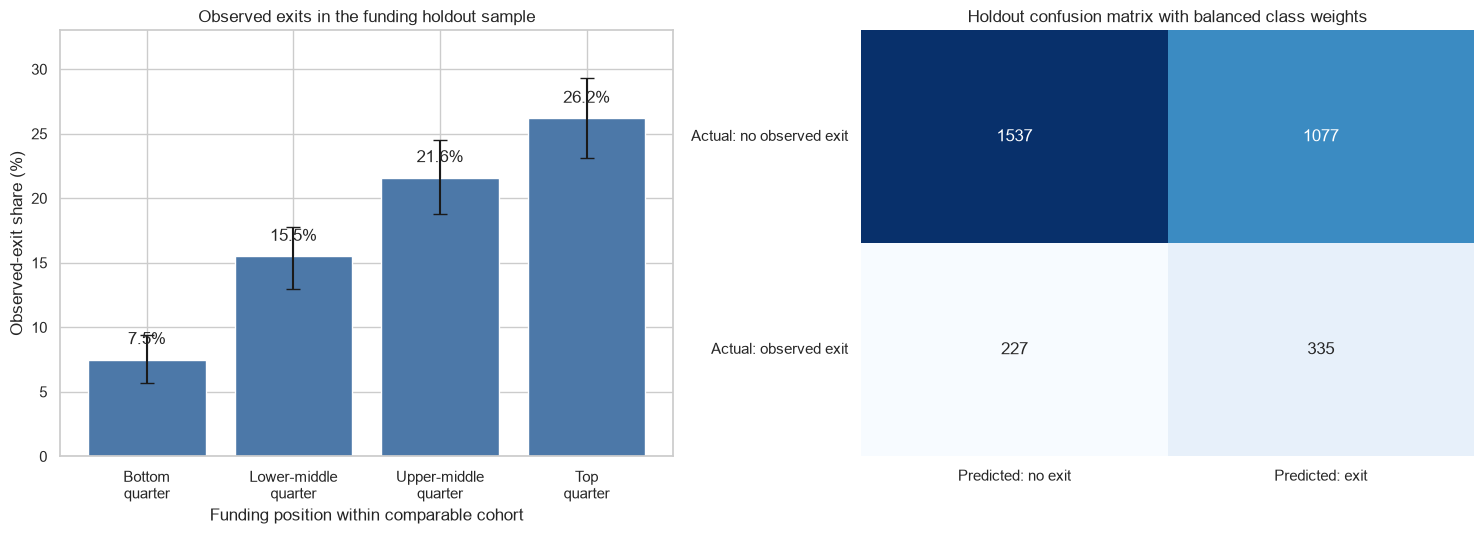

In [10]:
# Repeat the benchmark with three minimum peer-cohort sizes.
robustness_rows = []

for minimum_cohort_size in [20, 30, 50]:
    robust_cohorts = cohort_eligibility[
        (cohort_eligibility["funding_records"] >= minimum_cohort_size)
        & (cohort_eligibility["observed_exit_records"] >= 5)
    ].index

    robust_data = funding_base[
        funding_base["peer_cohort"].isin(robust_cohorts)
    ].copy()
    robust_data["funding_percentile"] = (
        robust_data.groupby("peer_cohort")["funding_total_usd"]
        .rank(pct=True, method="average")
    )
    robust_data["funding_quartile"] = pd.cut(
        robust_data["funding_percentile"],
        bins=[0, 0.25, 0.50, 0.75, 1],
        labels=quartile_order,
        include_lowest=True,
    )

    robust_rates = robust_data.groupby(
        "funding_quartile", observed=False
    )["observed_exit"].mean()

    bottom_rate = 100 * robust_rates.loc["Bottom quarter"]
    top_rate = 100 * robust_rates.loc["Top quarter"]

    robustness_rows.append({
        "Minimum cohort size": minimum_cohort_size,
        "Eligible cohorts": len(robust_cohorts),
        "Companies": len(robust_data),
        "Bottom-quarter exit share (%)": round(bottom_rate, 1),
        "Top-quarter exit share (%)": round(top_rate, 1),
        "Top-minus-bottom gap (percentage points)":
            round(top_rate - bottom_rate, 1),
    })

funding_robustness = pd.DataFrame(robustness_rows)
funding_robustness.to_csv(
    TABLE_DIR / "step8_funding_cohort_robustness.csv", index=False
)

print(funding_robustness.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

x_positions = np.arange(len(holdout_quartile_summary))
exit_rates = holdout_quartile_summary["Observed-exit share (%)"]
lower_error = exit_rates - holdout_quartile_summary["95% CI lower (%)"]
upper_error = holdout_quartile_summary["95% CI upper (%)"] - exit_rates

axes[0].bar(
    x_positions,
    exit_rates,
    color="#4C78A8",
    yerr=[lower_error, upper_error],
    capsize=5,
)
axes[0].set_title("Observed exits in the funding holdout sample")
axes[0].set_xlabel("Funding position within comparable cohort")
axes[0].set_ylabel("Observed-exit share (%)")
axes[0].set_xticks(x_positions)
axes[0].set_xticklabels(
    [
        "Bottom\nquarter",
        "Lower-middle\nquarter",
        "Upper-middle\nquarter",
        "Top\nquarter",
    ]
)
axes[0].set_ylim(0, 33)
for position, value in enumerate(exit_rates):
    axes[0].text(position, value + 1.2, f"{value:.1f}%", ha="center")

confusion_display = pd.DataFrame(
    funding_confusion_matrix,
    index=["Actual: no observed exit", "Actual: observed exit"],
    columns=["Predicted: no exit", "Predicted: exit"],
)
sns.heatmap(
    confusion_display,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    ax=axes[1],
)
axes[1].set_title("Holdout confusion matrix with balanced class weights")
axes[1].set_xlabel("")
axes[1].set_ylabel("")
axes[1].tick_params(axis="x", rotation=0)
axes[1].tick_params(axis="y", rotation=0)

save_figure("step8_03_funding_validation.png")

**Result note.** In the holdout sample, the observed-exit share rises from
7.5% in the bottom funding quarter to 26.2% in the top quarter. The gap is
18.6 percentage points, with a 95% bootstrap interval of roughly 15.2 to
22.3 points. Changing the minimum cohort size from 20 to 50 leaves the
full-data gap close to 18 percentage points. The association is robust,
but the modest model metrics show that relative funding explains only a
limited part of outcome differences.

# Validation summary

In [11]:
validation_summary = pd.DataFrame([
    {
        "Finding": "Health-risk classification",
        "Validation used":
            "70/30 replication, bootstrap interval, threshold sensitivity",
        "Main result":
            "Development and holdout High Risk shares are similar, but "
            "the exact rate changes substantially with the thresholds.",
        "Conclusion":
            "Stable descriptive rule; predictive validity not tested.",
    },
    {
        "Finding": "Failure archetype",
        "Validation used":
            "70/30 sector-stratified replication and sector stability",
        "Main result":
            "The dominant competitive pair repeats; detailed combinations "
            "and two sector factors change.",
        "Conclusion":
            "Broad archetype is stable; detailed sector claims are tentative.",
    },
    {
        "Finding": "Funding-outcome benchmark",
        "Validation used":
            "80/20 stratified holdout, balanced model, bootstrap intervals, "
            "cohort-size sensitivity",
        "Main result":
            "The positive funding-outcome association repeats, but holdout "
            "discrimination is modest.",
        "Conclusion":
            "Useful benchmark signal; not a standalone prediction or causal claim.",
    },
])

validation_summary.to_csv(
    TABLE_DIR / "step8_validation_summary.csv", index=False
)

print(validation_summary.to_string(index=False))

                   Finding                                                                        Validation used                                                                                                         Main result                                                            Conclusion
Health-risk classification                           70/30 replication, bootstrap interval, threshold sensitivity Development and holdout High Risk shares are similar, but the exact rate changes substantially with the thresholds.              Stable descriptive rule; predictive validity not tested.
         Failure archetype                               70/30 sector-stratified replication and sector stability                         The dominant competitive pair repeats; detailed combinations and two sector factors change.      Broad archetype is stable; detailed sector claims are tentative.
 Funding-outcome benchmark 80/20 stratified holdout, balanced model, bootstrap intervals, cohort-siz

## Language to use in the final report

| Supported wording | Avoid |
|---|---|
| Higher relative funding is **associated with** more observed exits. | More funding **causes** startup success. |
| Competitive factors **co-occur frequently** in failed-startup post-mortems. | Competition **caused** 58.2% of failures. |
| The health rule **flags** startups for investigation. | The rule **predicts** which startups will fail. |

## Final validation conclusion

The main Step 7 patterns survive basic validation, but their strength is
different:

1. The health finding is internally consistent but threshold-sensitive
   and synthetic.
2. The broad failure archetype is stable, while detailed sector findings
   need caution because samples are small.
3. The funding association is robust in a holdout sample, but its
   predictive performance is modest and it does not prove causation.

The practical use is diagnostic prioritization: identify what founders
should investigate next, then confirm it with the startup's own customer,
product, and financial evidence.